# Step 2 of MSM construction: dimensionality reduction

tICA vs PCA


Original feature sets dimensions:
- dihedrals: 66
- contacts: 42


Compression goal:
- 2d for visualization
- ~ 5d for MSM construction

Low dimensionality facilitates clustering, which is step 3 of MSM construction.

In [1]:
data_folder = "./data/"

import numpy as np
import deeptime as deep
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
binary_cmap = ListedColormap(['white', 'black'])

data_folder = "./data/"


#################################################
#################################################
#################################################

def free_energy_1d(y):
    hist, edges = np.histogram(y, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    p = hist + 1e-12
    F = - np.log(p)
    F -= F.min()
    return centers, F

### Load feature sets

In [2]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
#dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
#print(dihedrals.shape) # [radians] 

Data shape (1526041, 42)
Data size (MB) 512.749776


### MoSAIC clusters.

In [3]:
contacts = [
    tuple(x)
    for x in np.loadtxt(
        data_folder + "hp35.mindists2.ndx",
        comments="#",
        usecols=(0, 1),
        dtype=int
    )
]

cluster_dict = {
    1 : [(3,14), (3, 13), (6,14), (5, 14)],
    2: [(7, 12), (7, 13), (6,12), (7,11), (6, 11), (6, 17)],
    3: [(12,17), (12,16), (12,20), (13, 17)],
    4: [(18,25), (17,25), (20, 25)],
    5: [(24, 28), (20, 28), (25, 29)],
    6: [(29,35), (29,34), (30,35), (29,33)],
    7: [(10,34), (9,32), (10,29)]
}

def cluster_idx(contact_tuple):
    idx = None
    for i in cluster_dict.keys():
        if contact_tuple in cluster_dict[i]:
            idx = i
            continue
    if idx == None:
        idx = 8
    return idx


feature_index_list = [
    (
    contacts[i],
    cluster_idx(contacts[i])
    )
    for i in range(len(contacts))
]
distances[0]

array([0.93466, 1.91207, 1.54868, 0.78296, 0.41241, 1.59451, 0.29998,
       0.61086, 1.01362, 1.05544, 1.31336, 0.71373, 0.87927, 1.49558,
       0.99847, 1.83233, 1.11028, 0.7227 , 0.89451, 1.05284, 0.94158,
       0.54431, 0.79338, 0.68241, 1.87493, 2.35048, 1.86605, 1.37039,
       1.34872, 2.88011, 1.07451, 1.12263, 1.01026, 1.03784, 0.96202,
       1.10449, 1.15828, 1.09999, 0.96971, 0.754  , 0.49972, 0.52967])

## Sort features by cluster

In [4]:

# permutation that sorts by cluster index
sort_idx = np.argsort(
    [x[1] for x in feature_index_list]
)

distances = distances[:, sort_idx]
contacts = [contacts[i] for i in sort_idx]
feature_index_list = [feature_index_list[i] for i in sort_idx]
distances[0]

array([1.91207, 1.54868, 1.59451, 1.05544, 1.31336, 0.61086, 1.01362,
       1.49558, 0.71373, 0.87927, 1.05284, 0.89451, 0.7227 , 0.94158,
       1.34872, 1.86605, 1.87493, 1.03784, 2.88011, 0.96202, 0.96971,
       0.754  , 0.52967, 0.49972, 1.11028, 1.83233, 0.99847, 0.68241,
       0.78296, 0.41241, 1.09999, 1.15828, 1.10449, 0.29998, 1.01026,
       1.12263, 1.07451, 1.37039, 2.35048, 0.54431, 0.79338, 0.93466])

## Preprocessing: smoothing the time series


Authors apply a Gaussian low-pass filter, which is basically a moving average with gaussian weights instead of equal weights. There are several theoretical reasons why a Gaussian filter should be preferrable to a simple MA.


However, the goal simply remains smoothing out the signal.


Why would you want to do that? See handwritten notes. It is expected to lower the uncertainties of cluster assignation and it is suggested by the authors as an alternative procedure to *dynamic core sets*.

## PCA

In [5]:
print(np.min(distances), np.max(distances)) # [nm]

0.16005 4.05262


In [6]:
pca = PCA()
pca.fit(distances)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [7]:
eigvecs = pca.components_ # components, space dimension (42, 42), ordered by decreasing eigval
eigvals = pca.explained_variance_

In [8]:
Y = pca.fit_transform(distances) # rotate the dataset onto the orthonormal basis of eigenvectors
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
max_pcs = eigvecs.shape[0]         # shape: (n_pcs, n_features)

**Comments**: the free energy curve of the first PC clearly displays a bimodal shape. This suggests that it correlates strongly with the folding process, and the two basins might correspond to the "folded state" and the "unfolded state". A bimodal structure is more or less visible up to the 5th PC, then it disappears, suggesting that the remaining components might describe "secondary" processes that are not strictly connected to the folding process.

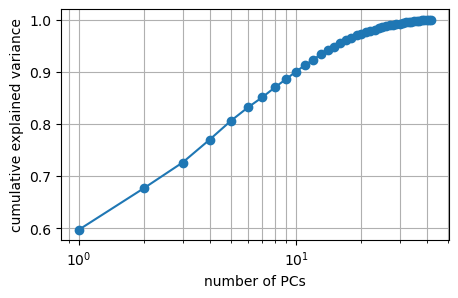

In [9]:
fig, ax = plt.subplots(figsize = (5, 3))
ax.plot(np.arange(1, max_pcs + 1), cum_explained, marker = "o")
ax.set_xscale("log", base = 10)
ax.set_xlabel("number of PCs")
ax.set_ylabel("cumulative explained variance")
ax.grid(which = "both")

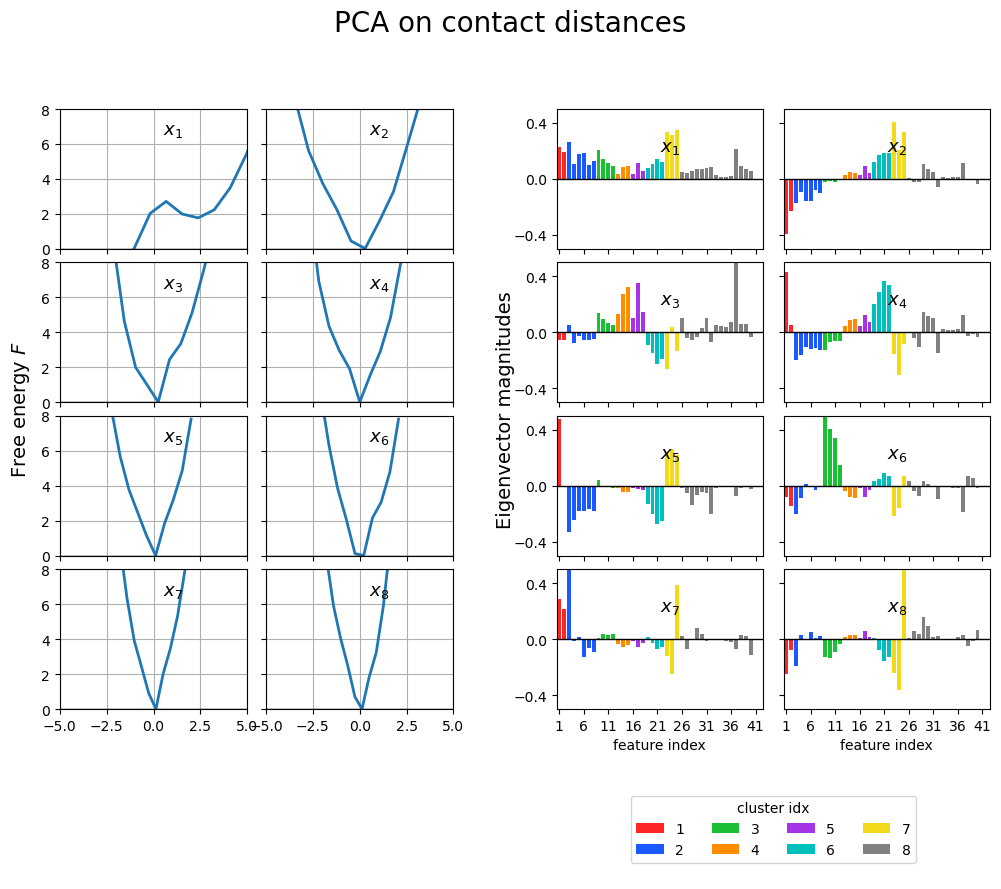

In [11]:
## DO NOT CHANGE THESE COLORS
# they are the same as used in the pymol script

colors = [
[1.00, 0.15, 0.15],
[0.10, 0.35, 1.00],
[0.10, 0.75, 0.20],
[1.00, 0.55, 0.00],
[0.65, 0.20, 0.90],
[0.00, 0.75, 0.75],
[0.95, 0.85, 0.10],
"grey"
]

fig = plt.figure(figsize=(12, 10))

# Outer grid controls spacing between big panels
outer = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 1.1],
    height_ratios = [3, 0.5],
    wspace=0.25,   # separation between panels a and b
)

##################################
####### Labels #####################
ax_label = fig.add_subplot(outer[0, 0])
ax_label.set_frame_on(False)
ax_label.tick_params(
    left=False,
    labelleft=False,
    bottom=False,
    labelbottom=False
)
ax_label.set_ylabel(
    "Free energy $F$",
    labelpad=20,
    fontsize=14
)

ax_label = fig.add_subplot(outer[0, 1])
ax_label.set_frame_on(False)
ax_label.tick_params(
    left=False,
    labelleft=False,
    bottom=False,
    labelbottom=False
)
ax_label.set_ylabel(
    "Eigenvector magnitudes",
    labelpad=30,
    fontsize=14
)


# Inner grids: glued subplots
gs_a = outer[0, 0].subgridspec(4, 2, wspace=0.1, hspace=0.1)
gs_b = outer[0, 1].subgridspec(4, 2, wspace=0.1, hspace=0.1)



# ---------- a: free energies along PCs ----------
axs_a = []
for i in range(8):
    ax = fig.add_subplot(gs_a[i // 2, i % 2])
    axs_a.append(ax)
    x, F = free_energy_1d(Y[:, i])
    ax.plot(x, F, lw=2)
    ax.axhline(0, color="black", lw=1)
    ax.set_xlim(-5, + 5)
    ax.set_ylim(0, min(8, F.max()))
    ax.text(0.55, 0.82, rf"$x_{i+1}$", transform=ax.transAxes, fontsize=13)
    if i % 2 == 1:
        ax.tick_params(labelleft=False)
    if i < 6:
        ax.tick_params(labelbottom=False)
    ax.grid()

# ---------- b: eigenvectors ----------
axs_b = []
for i in range(8):
    ax = fig.add_subplot(gs_b[i // 2, i % 2])
    axs_b.append(ax)
    for j in np.arange(0, distances.shape[1]):
        ax.bar(j-1, eigvecs[i][j], color = colors[feature_index_list[j][1] - 1], width=0.8)
    ax.axhline(0, color="black", lw=1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([-0.4, 0, 0.4])
    ax.set_xlim(0.5,  distances.shape[1] + 0.5)
    ax.set_xticks(np.arange(1, distances.shape[1] + 1, 5))
    ax.text(0.50, 0.70, rf"$x_{i+1}$", transform=ax.transAxes, fontsize=13)
    if i % 2 == 1:
        ax.tick_params(labelleft=False)
    if i < 6:
        ax.tick_params(labelbottom=False)
    if i > 5:
        ax.set_xlabel("feature index")


gs_legend = outer[1, 1].subgridspec(1, 1, wspace=0.1, hspace=0.1)
ax_leg = fig.add_subplot(gs_legend[0, 0])

from matplotlib.patches import Patch

ax_leg.axis("off")

handles = [
    Patch(facecolor=colors[k], label=f"{k+1}")
    for k in range(0, 8)
]

ax_leg.legend(
    title = "cluster idx",
    handles=handles,
    loc="center",
    frameon=True,
    ncol=4
)

plt.suptitle("PCA on contact distances", fontsize = 20)
plt.show()